# Análisis estadístico de calidad del café arábica (CQI)

## Introducción

**Coffe Quality Institute** o (CQI) es una organización sin ánimos de lucro que se dedica a mejorar el valor y calidad del café en el mundo, con el propósito de promover café de calidad a través de la investigación, entrenamiento y programas de certificación.

Tras eso, se ha realizado una base de datos con el propósito de saber más al respecto con la calidad del café, es por ello que ha surgido este tipo de preguntas:

- ¿Qué país produce el café mejor calificado?
- ¿Qué atributo del café tiene más relación con la calificación total?
- ¿Hay diferencia estadística en la calidad del café entre continentes?

En este proyecto de análisis estadistico de datos, se identificó cuál es el país que se produce el mejor café, y para su realización se hicieron estas acciones

Para determinar el mejor café:

- Cálculo del promedio de Total.Cup.Points por país de origen y visualización en gráfica de barras.

Para determinar el mejor atributo:

- Cálculo de correlación entre Total.Cup.Points y los atributos individuales: Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Sweetness con una tabla de correlaciones.

- Identificación de atributo con la correlación más alta con un Scatterplot, comparado al Total.Cup.Points.

Para determinar si la diferencia es real o ruido:

- Clasificación por continente por un boxplot
- Prueba estadística a través de ANOVA / Kruskal-Wallis.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


## Descripción general

Para el estudio del análisis, se realizó primero un evaluación de la forma y limpieza del archivo *"dataset"*, este contiene una lista de paises, compañías, productores, atributos, entre otros. La limpieza y manipulación de datos, es necesario para lograr una mejor comprensión de los datos y evitar conclusiones malinterpretadas.

In [2]:
df = pd.read_csv('df_arabica_clean.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    str    
 15  Grading Date     

In [4]:
print("\nDataset dimensions:")
print(df.shape)


Dataset dimensions:
(207, 41)


In [5]:
print("\nCoffee data columns:")
print(df.columns.tolist())


Coffee data columns:
['Unnamed: 0', 'ID', 'Country of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Expiration', 'Certification Body', 'Certification Address', 'Certification Contact']


In [6]:
df.describe()

,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


In [7]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [8]:
print("Dimensiones:", df.shape)
print("\nNulos en las columnas que se usan:")
cols_uso = ['Country of Origin', 'Total Cup Points', 'Aroma', 'Flavor', 'Aftertaste',
            'Acidity', 'Body', 'Balance', 'Sweetness']
print(df[cols_uso].isna().sum())

Dimensiones: (207, 40)

Nulos en las columnas que se usan:
Country of Origin    0
Total Cup Points     0
Aroma                0
Flavor               0
Aftertaste           0
Acidity              0
Body                 0
Balance              0
Sweetness            0
dtype: int64


In [9]:
df.head(15)

,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,曾福森,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
5,5,Guatemala,La Colina,"The 2022 Pacific Rim Coffee Summit,GT02",Dinámica Café,NaN,Taiwan Coffee Laboratory,1668,Chimaltenango,Emilio Antonio Medina Garcia,...,87.00,10.7,0,0,green,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
6,6,Taiwan,野牡丹咖啡莊園 Melastoma Coffee Estate,"The 2022 Pacific Rim Coffee Summit,T034",野牡丹咖啡,NaN,Taiwan Coffee Laboratory,1250,Chiayi,黃保錫,...,86.92,9.1,0,0,green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
7,7,Taiwan,七彩琉璃咖啡莊園 Chi Tsai Liu Li Ecological Farm,"The 2022 Pacific Rim Coffee Summit,T050",七彩琉璃咖啡莊園,NaN,Taiwan Coffee Laboratory,1200,Chiayi,莊家榮,...,86.75,10.0,0,0,yellow green,1,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
8,8,Taiwan,亮軒咖啡莊園 Liang Xuan Coffee Farm,"The 2022 Pacific Rim Coffee Summit,T018",亮軒咖啡莊園,NaN,Taiwan Coffee Laboratory,1250,Chiayi,鍾旭亮,...,86.67,10.8,0,0,greenish,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
9,9,"Tanzania, United Republic Of",MASHIMA AMCOS,CN 4127230034/4189230113,GOURMET COFFEE MILL,033/DE/503/002 and 033/DE/268/002,DORMAN (T) LIMITED,1400-1700,KILIMANJARO,DORMAN (T) LIMITED,...,86.50,11.0,0,0,greenish,0,"February 1st, 2024",Kenya Coffee Traders Association,"P.O. Box 646 00100Nairobi, Kenya, Denniss Prit...",Benson Kibicho Kamau - +254 786 821 621


Se eliminó la columna `Unnamed: 0` por considerarlo innecesario, además que no se han encontrado datos duplicados

## Promedio de Total Cup Points por país de origen

Para el cálculo del promedio, primero se agruparon el total por los países con el "Total Cup Points" con el propósito de identificar la puntuación total, y en base a eso, se calculó el promedio por .mean(), creando una tabla con el promedio y la cantidad de muestras, así como una gráfica para su visualización.

In [10]:
# Total cup points by country of origin

total_por_pais = (
    df.groupby('Country of Origin')['Total Cup Points'].sum()
    .sort_values(ascending=False)
    .round(3)
)
print ("\nTotal de Cup Points por País:")
total_por_pais



Total de Cup Points por País:


Country of Origin
Taiwan                          5145.37
Guatemala                       1770.33
Colombia                        1593.67
Honduras                        1082.67
Thailand                         993.93
Ethiopia                         934.57
Brazil                           818.83
Costa Rica                       669.92
Nicaragua                        573.25
El Salvador                      570.73
Tanzania, United Republic Of     508.41
United States (Hawaii)           418.25
Vietnam                          331.57
Mexico                           330.84
Peru                             329.33
Uganda                           251.75
Indonesia                        251.08
Laos                             250.17
Kenya                            167.42
Panama                           167.25
Madagascar                        84.25
Myanmar                           83.67
Name: Total Cup Points, dtype: float64

In [11]:
# Promedio de Total Cup Points por país de origen

promedio_por_país = (
    df.groupby('Country of Origin')['Total Cup Points']
    .agg(promedio='mean', núm_de_muestras='count')
    .sort_values('promedio', ascending=False)
    .round(2)
)
print("\nPromedio de total cup points por país de origen:")
promedio_por_país


Promedio de total cup points por país de origen:


,promedio,núm_de_muestras
Country of Origin,,
Ethiopia,84.96,11
"Tanzania, United Republic Of",84.74,6
Taiwan,84.35,61
Guatemala,84.30,21
Madagascar,84.25,1
Uganda,83.92,3
Colombia,83.88,19
Costa Rica,83.74,8
Kenya,83.71,2


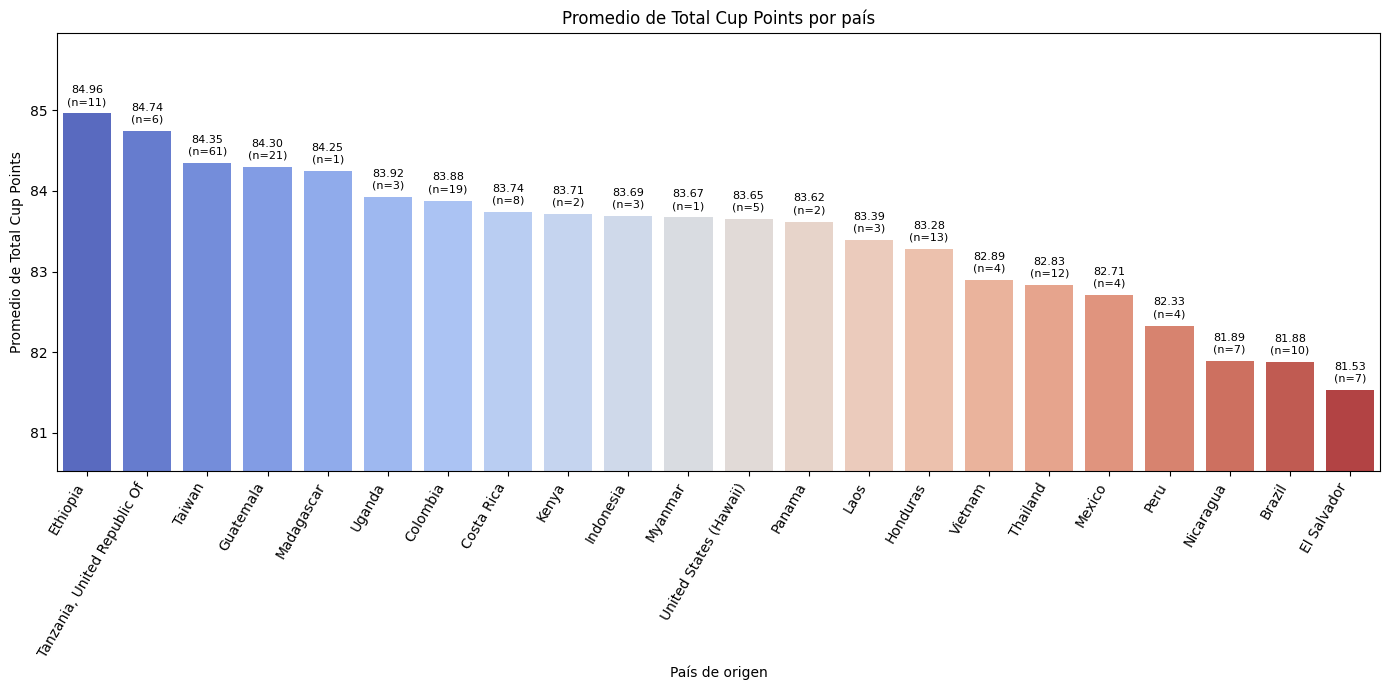

In [12]:
# graphic representation of the top average cup points by country of origin

orden = promedio_por_país.index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=promedio_por_país.reset_index(), x='Country of Origin', y='promedio', 
            hue='Country of Origin', palette="coolwarm", order=orden)

# Etiqueta con promedio y num de muestras sobre cada barra
for i, (prom, n) in enumerate(zip(promedio_por_país['promedio'], promedio_por_país['núm_de_muestras'])):
    ax.text(i, prom + 0.08, f"{prom:.2f}\n(n={n})", ha='center', va='bottom', fontsize=8)

ax.set_ylim(promedio_por_país['promedio'].min() - 1, promedio_por_país['promedio'].max() + 1)  # eje truncado: aclararlo
ax.set_title('Promedio de Total Cup Points por país')
ax.set_xlabel('País de origen')
ax.set_ylabel('Promedio de Total Cup Points')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [13]:
fiables = promedio_por_país[promedio_por_país['núm_de_muestras'] >= 5]
print(f"Mejor promedio (n>=5): {fiables.index[0]} con {fiables['promedio'].iloc[0]:.2f} puntos (n={fiables['núm_de_muestras'].iloc[0]}).")
print(f"Peor promedio (n>=5): {fiables.index[-1]} con {fiables['promedio'].iloc[-1]:.2f} puntos (n={fiables['núm_de_muestras'].iloc[-1]}).")
print("\nPaíses con n < 5 (interpretar con cautela):", promedio_por_país[promedio_por_país['núm_de_muestras'] < 5].index.tolist())

Mejor promedio (n>=5): Ethiopia con 84.96 puntos (n=11).
Peor promedio (n>=5): El Salvador con 81.53 puntos (n=7).

Países con n < 5 (interpretar con cautela): ['Madagascar', 'Uganda', 'Kenya', 'Indonesia', 'Myanmar', 'Panama', 'Laos', 'Vietnam', 'Mexico', 'Peru']


Etiopía obtiene el **mayor promedio** entre los países con muestra suficiente con *84.96 puntos*. Le siguen Tanzania *84.74 puntos* con 6 muestras, Taiwán *84.35 puntos* con 61 muestras y Guatemala *84.30 puntos* con 21 muestras. Mientras que el **más bajo** fué El Salvador con *81.53 puntos*, Brasil *81.88* y Nicaragua *81.89*, así que entre el primero y el último hay unos 3.4 puntos de diferencia.
Los países con pocas muestras (n < 5) pueden aparecer arriba o abajo solo por azar, por lo que no se comparan directamente. Madagascar (84.25) y Myanmar (83.67) tienen una sola muestra, y otros ocho países tienen entre 2 y 4. Sus promedios no son comparables con los demás, por eso quedaron fuera de la lectura principal.

## Correlación entre Total Cup Points y los atributos

Hay atributos que tienen que ver con la puntuación del café, para saber cuáles atributos tienen relación, se ha hecho una matriz de correlación entre los *"Cup Points"* y los atributos que son `Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body`, `Balance`, `Sweetness`. Además que se calculó la robustez del atributo a través de la *correlación de Spearman*.

**Notas:**  
- El atributo `Sweetness` posee el mísmo número en todas las filas (vale 10), es por ello que no es visible en las tablas porque no aporta información para explicar el puntaje
- `Total Cup Points` es la suma de los atributos sensoriales (más Uniformity, Clean Cup y Overall), parte de esa correlación alta es mecánica.



In [16]:
df['Sweetness'] = df['Sweetness'].fillna(df['Sweetness'].mean())

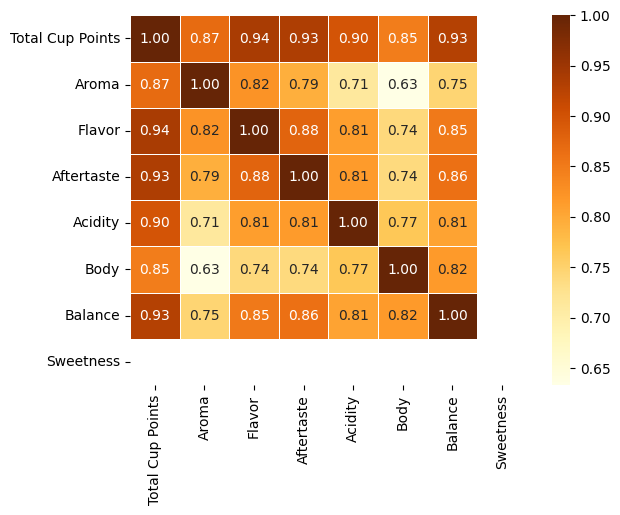

In [17]:
#correlations between cup points and Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Sweetness

matrix_corr = df[['Total Cup Points', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Sweetness']].corr()

colormap = sns.color_palette("YlOrBr", as_cmap=True)
sns.heatmap(matrix_corr, annot=True, cmap=colormap, fmt=".2f", linewidths=0.5)
plt.show()


In [18]:
atributos = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Sweetness']

# Sweetness (o cualquier atributo) con varianza cero no tiene correlación definida
constantes = [a for a in atributos if df[a].std() == 0]
if constantes:
    print("Atributos constantes (correlación indefinida):", constantes)

Atributos constantes (correlación indefinida): ['Sweetness']


In [19]:
corr = (
    df[atributos].corrwith(df['Total Cup Points'])
    .sort_values(ascending=False)
    .round(3)
    .to_frame('r de Pearson')
)
corr

C:\Users\IndioTemplario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\IndioTemplario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,r de Pearson
Flavor,0.939
Aftertaste,0.935
Balance,0.930
Acidity,0.897
Aroma,0.869
Body,0.847
Sweetness,NaN


In [20]:
# Robustez: correlación de Spearman (no asume linealidad ni normalidad)
corr_sp = df[atributos].corrwith(df['Total Cup Points'], method='spearman').round(3)
comparacion = corr.join(corr_sp.rename('r de Spearman'))
comparacion

C:\Users\IndioTemplario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,r de Pearson,r de Spearman
Flavor,0.939,0.925
Aftertaste,0.935,0.927
Balance,0.930,0.924
Acidity,0.897,0.885
Aroma,0.869,0.850
Body,0.847,0.831
Sweetness,NaN,NaN


Atributo más correlado: Flavor (r = 0.939). Le sigue Aftertaste (r = 0.935).


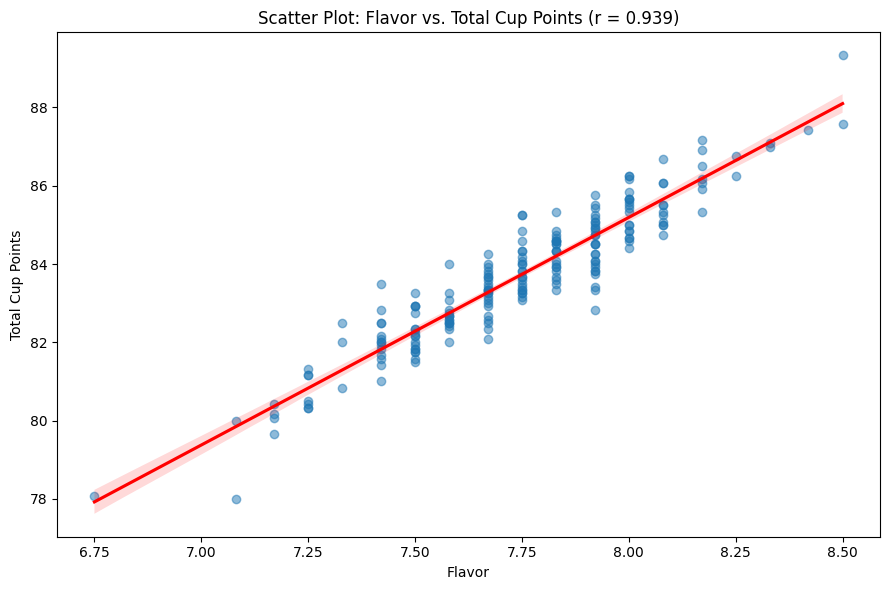

In [21]:
# scatter plot del atributo más correlacionado vs. Total.Cup.Points
mejor = corr['r de Pearson'].idxmax()
r_mejor = corr.loc[mejor, 'r de Pearson']
segundo = corr['r de Pearson'].sort_values(ascending=False).index[1]
print(f"Atributo más correlado: {mejor} (r = {r_mejor:.3f}). Le sigue {segundo} (r = {corr.loc[segundo, 'r de Pearson']:.3f}).")


plt.figure(figsize=(9, 6))
sns.regplot(data=df, x=mejor, y='Total Cup Points', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Scatter Plot: {mejor} vs. Total Cup Points (r = {r_mejor:.3f})')
plt.tight_layout()
plt.show()


El Atributo **"Flavor"** es el que más se relaciona con la calificación total.
Con un R² de 0.88: explica cerca del 88 % de la variación del puntaje total. Le siguen muy de cerca Aftertaste (0.935) y Balance (0.930), y la diferencia entre los tres es mínima. Después vienen Acidity (0.897), Aroma (0.869) y Body (0.847). Spearman da el mismo orden general (Flavor 0.925, Aftertaste 0.927), así que la relación es sólida y no depende de valores extremos.

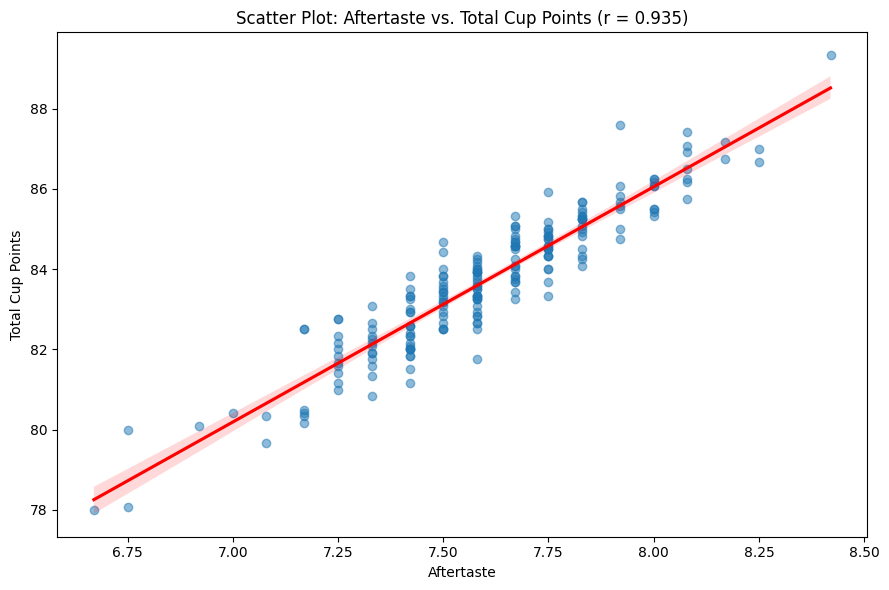

In [22]:
# diagrama de scatter plot del atributo "aftertaste" vs. Total.Cup.Points

plt.figure(figsize=(9, 6))
sns.regplot(data=df, x=segundo, y='Total Cup Points', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Scatter Plot: {segundo} vs. Total Cup Points (r = {corr.loc[segundo, "r de Pearson"]:.3f})')
plt.tight_layout()
plt.show()

En el atributo `Aftertaste` no hay tanta diferencia con la comparación con la calificación total

## Diferencias de calidad entre continentes

### Graficación

Cada continente influye en gran medida la calidad del café por razones climáticas y geográficas obviamente, y para poder ver las diferencias de cada una, se ha agrupado los países por continente. Luego se ha clasificado los países por continente. Comparando así su distribución de Total.Cup.Points entre grupos con un boxplot. 

In [24]:
# agrupar países por continente y calcular la media de Total Cup Points
continentes = {
    'brazil': 'Americas', 'colombia': 'Americas', 'costa rica': 'Americas', 'el salvador': 'Americas',
    'guatemala': 'Americas', 'honduras': 'Americas', 'mexico': 'Americas', 'nicaragua': 'Americas',
    'panama': 'Americas', 'peru': 'Americas', 'united states (hawaii)': 'Americas',
    'ethiopia': 'Africa', 'kenya': 'Africa', 'tanzania, united republic of': 'Africa',
    'uganda': 'Africa', 'madagascar': 'Africa',
    'indonesia': 'Asia', 'laos': 'Asia', 'myanmar': 'Asia', 'taiwan': 'Asia',
    'thailand': 'Asia', 'vietnam': 'Asia',
}

df['Continent'] = df['Country of Origin'].str.strip().str.lower().map(continentes)

print(df['Continent'].value_counts())
print()
print(df.groupby('Continent')['Total Cup Points'].agg(['mean', 'median', 'std', 'count']).round(2))

Continent
Americas    100
Asia         84
Africa       23
Name: count, dtype: int64

            mean  median   std  count
Continent                            
Africa     84.63   84.50  1.14     23
Americas   83.25   83.33  1.83    100
Asia       84.00   84.08  1.59     84


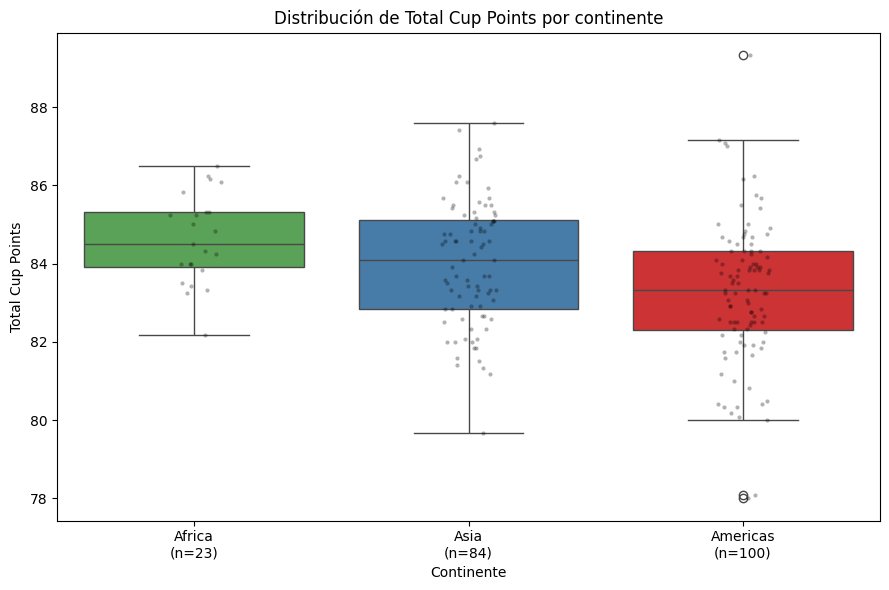

In [25]:
# distribución de Total cup points entre grupos por boxplot

orden_c = df.groupby('Continent')['Total Cup Points'].median().sort_values(ascending=False).index.tolist()
n_por_c = df['Continent'].value_counts()

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Continent', y='Total Cup Points', hue='Continent',
            order=orden_c, palette='Set1', legend=False)
sns.stripplot(data=df, x='Continent', y='Total Cup Points', order=orden_c,
            color='black', alpha=0.3, size=3)
plt.xticks(range(len(orden_c)), [f"{c}\n(n={n_por_c[c]})" for c in orden_c])
plt.title('Distribución de Total Cup Points por continente')
plt.xlabel('Continente')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.show()


A pesar que `Americas` posee más *números de muestra*, unas 100 , `Africa` es el que posee el promedio más alto con un promedio de *84.63 puntos* a pesar de que este último no tenga muchos *números de muestra*, es decir unas 23

### Pruebas de estadística

Para determinar la diferencia de cada uno influye, se aplicaron dos pruebas estadísticas, una de ellas es la *ANOVA* con eta², que sirve para comparar las medias de los tres grupos, y así identificar las diferencias de cada una. También se hizo con la *Kruskal-Wallis* con epsilon² para comprobar si existen diferencias significativas entre las tres muestras, y un post-hoc (Tukey y Mann-Whitney con Bonferroni) para obtener un resultado global significativo, evitando falsos positivos y localizar diferencias. Eso se realizó para determinar si la diferencia es real o ruido.

In [30]:
grupos = {c: df.loc[df['Continent'] == c, 'Total Cup Points'] for c in orden_c}

# --- Supuestos del ANOVA ---
print("Shapiro-Wilk (normalidad por grupo):")
for c, g in grupos.items():
    w, p = stats.shapiro(g)
    print(f"  {c:10s} W={w:.3f}  p={p:.4f}  {'normal' if p > 0.05 else 'NO normal'}")

lev_stat, p_levene = stats.levene(*grupos.values(), center='median')
print(f"\nLevene (igualdad de varianzas): estadístico={lev_stat:.3f}  p={p_levene:.4f}  "
        f"{'varianzas homogéneas' if p_levene > 0.05 else 'varianzas NO homogéneas'}")

Shapiro-Wilk (normalidad por grupo):
  Africa     W=0.969  p=0.6636  normal
  Asia       W=0.988  p=0.6439  normal
  Americas   W=0.978  p=0.0938  normal

Levene (igualdad de varianzas): estadístico=1.640  p=0.1966  varianzas homogéneas


In [31]:
# Prueba estadística para determinar si hay diferencias significativas en la calidad del café entre continentes
# prueba ANOVA (Analysis of Variance) para comparar las medias de Total Cup Points entre continentes

f_stat, p_anova = stats.f_oneway(*grupos.values())

# Tamaño del efecto: eta cuadrado = SC entre grupos / SC total
y = df['Total Cup Points']
ss_total = ((y - y.mean()) ** 2).sum()
ss_between = sum(len(g) * (g.mean() - y.mean()) ** 2 for g in grupos.values())
eta2 = ss_between / ss_total

print(f"ANOVA: F = {f_stat:.3f}, p = {p_anova:.5f}, eta² = {eta2:.3f}")
print("  ->", "Diferencias significativas entre continentes." if p_anova < 0.05
        else "Sin evidencia de diferencias entre continentes.")

ANOVA: F = 8.479, p = 0.00029, eta² = 0.077
  -> Diferencias significativas entre continentes.


In [32]:
# prueba Kruskal-Wallis para comparar las distribuciones de Total Cup Points entre continentes
h_stat, p_kw = stats.kruskal(*grupos.values())

# Tamaño del efecto: epsilon cuadrado = H (n + 1) / (n² - 1)
n_total = len(y)
eps2 = h_stat * (n_total + 1) / (n_total ** 2 - 1)

print(f"Kruskal-Wallis: H = {h_stat:.3f}, p = {p_kw:.5f}, epsilon² = {eps2:.3f}")
print("  ->", "Diferencias significativas entre continentes." if p_kw < 0.05
        else "Sin evidencia de diferencias entre continentes.")

Kruskal-Wallis: H = 17.686, p = 0.00014, epsilon² = 0.086
  -> Diferencias significativas entre continentes.


In [33]:
# --- Post-hoc: ¿qué pares de continentes difieren? ---

from itertools import combinations

# Tras ANOVA: Tukey HSD
print("Tukey HSD (tras ANOVA):")
print(stats.tukey_hsd(*grupos.values()))
print("Orden de grupos:", list(grupos.keys()))

# Tras Kruskal-Wallis: Mann-Whitney por pares con corrección de Bonferroni
pares = list(combinations(grupos.keys(), 2))
print("\nMann-Whitney por pares (Bonferroni):")
for a, b in pares:
    u, p = stats.mannwhitneyu(grupos[a], grupos[b], alternative='two-sided')
    p_adj = min(p * len(pares), 1.0)
    print(f"  {a} vs {b}: U={u:.1f}  p_ajustado={p_adj:.4f}  {'*' if p_adj < 0.05 else 'n.s.'}")

Tukey HSD (tras ANOVA):
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.629     0.249    -0.300     1.557
 (0 - 2)      1.375     0.001     0.463     2.288
 (1 - 0)     -0.629     0.249    -1.557     0.300
 (1 - 2)      0.747     0.008     0.163     1.331
 (2 - 0)     -1.375     0.001    -2.288    -0.463
 (2 - 1)     -0.747     0.008    -1.331    -0.163

Orden de grupos: ['Africa', 'Asia', 'Americas']

Mann-Whitney por pares (Bonferroni):
  Africa vs Asia: U=1200.5  p_ajustado=0.2276  n.s.
  Africa vs Americas: U=1730.5  p_ajustado=0.0005  *
  Asia vs Americas: U=5251.0  p_ajustado=0.0105  *


## Conclusiones

Se cumplen los supuestos del ANOVA: Shapiro-Wilk indica normalidad en los tres grupos (p ≥ 0.09) y Levene indica varianzas homogéneas (p = 0.197). Ambas pruebas coinciden:

- ANOVA: F = 8.479, p = 0.0003, eta² = 0.077.
- Kruskal-Wallis: H = 17.686, p = 0.0001, epsilon² = 0.086.

Hay diferencias significativas entre continentes, pero el tamaño del efecto es de pequeño a moderado: el continente explica solo alrededor del 8 % de la variación en la calidad. Los post-hoc (Tukey y Mann-Whitney con Bonferroni) coinciden:

- África > América (diferencia de 1.38 puntos; p = 0.001 en Tukey, p = 0.0005 en Mann-Whitney).
- Asia > América (0.75 puntos; p = 0.008 en Tukey, p = 0.0105 en Mann-Whitney).
- África y Asia no difieren de forma significativa (p = 0.249 en Tukey, p = 0.228 en Mann-Whitney).

En conjunto, América obtiene puntajes menores que África y Asia, pero la diferencia es modesta. Hay que tomarla con cautela: África tiene pocos registros (23), Taiwán aporta 61 de los 84 de Asia, y hay varios lotes por país, así que las observaciones no son totalmente independientes.
